In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# cd /content/drive/My Drive/Colab Notebooks/

/content/drive/My Drive/Colab Notebooks


In [3]:
import os
os.listdir()

['Deep Learning',
 'data',
 'Copy of Neural Machine Translation',
 'transformer_model.pth',
 'MachineTranslation.ipynb']

# Import Library

In [4]:
import os
import re
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time
import math
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
from torch.amp import autocast, GradScaler

# Data

In [6]:
folder = 'data'

vocab_en = os.path.join(folder, 'vocab.en')
vocab_vi = os.path.join(folder, 'vocab.vi')

train_en = os.path.join(folder, 'train.en')
train_vi = os.path.join(folder, 'train.vi')

validation_en = os.path.join(folder, 'tst2012.en')
validation_vi = os.path.join(folder, 'tst2012.vi')

test_en = os.path.join(folder, 'tst2013.en')
test_vi = os.path.join(folder, 'tst2013.vi')

In [7]:
def preprocess_sentence(w):
    """
    Hàm làm sạch dữ liệu.

    Tham số:
      w: câu đầu vào

    Returns:
      Câu đã được làm sạch, có thêm <start> và <end> nhưng không lặp lại các từ nếu đầu vào đã có.
    """
    # Chuyển thành chữ thường và loại bỏ khoảng trắng dư thừa ở đầu, cuối
    w = w.lower().strip()

    # Nếu có xuất hiện thẻ <start> và <end> trong chuỗi, loại bỏ chúng đi.
    w = re.sub(r'<\s*start\s*>', '', w)
    w = re.sub(r'<\s*end\s*>', '', w)

    # Loại bỏ các ký tự đặc biệt & các dấu câu, chỉ giữ lại chữ, số và khoảng trắng
    w = re.sub(r"[^\w0-9 ]+", " ", w)

    # Rút gọn nhiều khoảng trắng thành 1 khoảng trắng
    w = re.sub(r"[\s]+", " ", w)

    # Xóa khoảng trắng đầu và cuối chuỗi sau khi xử lý
    w = w.strip()

    # Thêm <start> và <end> ở đầu và cuối chuỗi để model nhận biết vị trí bắt đầu và kết thúc dự đoán
    w = '<start> ' + w + ' <end>'

    return w

**Test preprocess_sentence function**

In [8]:
# Ví dụ
en_sentence = u"<start> May I borrow this book? <end>"
vi_sentence = u"<start> Mình mượn cuốn sách này được không? <end>"

print(preprocess_sentence(en_sentence))
print(preprocess_sentence(vi_sentence))

<start> may i borrow this book <end>
<start> mình mượn cuốn sách này được không <end>


## The function create_dataset() imports data from the specified path, cleans the data, and returns English-Vietnamese sentence pairs

In [9]:
def create_dataset(input_path, target_path):
  """
  Hàm nhập dữ liệu từ đường dẫn, làm sạch và trả về các cặp câu Anh - Việt

  Tham số:
    input_path: đường dẫn dữ liệu đầu vào
    target_path: đường dẫn dữ liệu đầu ra

  Returns:
    List các cặp câu Anh - Việt tương ứng
  """

  input_lines = open(input_path, encoding='UTF-8').read().strip().split('\n')
  target_lines = open(target_path, encoding='UTF-8').read().strip().split('\n')

  word_pairs = []
  for i in range(len(input_lines)):
    pi = preprocess_sentence(input_lines[i])
    pt = preprocess_sentence(target_lines[i])
    word_pairs.append([pi, pt])

  return word_pairs

def print_samples(pairs, number):
  """
  Hàm in ra một số câu Anh - Việt

  Tham số:
    pairs: list các cặp câu Anh - Việt
    number: số lượng các cặp câu cần in

  Returns:
    None
  """

  for i in range(number):
    print(pairs[i][0])
    print(pairs[i][1])



In [10]:
train_pairs = create_dataset(train_en, train_vi)

val_pairs = create_dataset(validation_en, validation_vi)

test_pairs = create_dataset(test_en, test_vi)

print_samples(train_pairs, 5)

<start> rachel pike the science behind a climate headline <end>
<start> khoa học đằng sau một tiêu đề về khí hậu <end>
<start> in 4 minutes atmospheric chemist rachel pike provides a glimpse of the massive scientific effort behind the bold headlines on climate change with her team one of thousands who contributed taking a risky flight over the rainforest in pursuit of data on a key molecule <end>
<start> trong 4 phút chuyên gia hoá học khí quyển rachel pike giới thiệu sơ lược về những nỗ lực khoa học miệt mài đằng sau những tiêu đề táo bạo về biến đổi khí hậu cùng với đoàn nghiên cứu của mình hàng ngàn người đã cống hiến cho dự án này một chuyến bay mạo hiểm qua rừng già để tìm kiếm thông tin về một phân tử then chốt <end>
<start> i apos d like to talk to you today about the scale of the scientific effort that goes into making the headlines you see in the paper <end>
<start> tôi muốn cho các bạn biết về sự to lớn của những nỗ lực khoa học đã góp phần làm nên các dòng tít bạn thường thấ

### It then computes the statistics on the length and the number of sentences in the datasets

In [11]:
def draw_diagram(pairs, name="Dataset", bins=30, ymax=300):
    num_words_input = [len(pair[0].split()) for pair in pairs]
    num_words_output = [len(pair[1].split()) for pair in pairs]

    print(f'--- {name} ---')
    print('Total pairs:', len(pairs))
    print('Total input words:', sum(num_words_input))
    print('Average input length:', sum(num_words_input)/len(num_words_input))
    print('Max input length:', max(num_words_input))

    plt.hist(num_words_input, bins)
    plt.xlabel('Input Sequence Length')
    plt.ylabel('Frequency')
    plt.title(f'{name} - Input')
    plt.axis([0, max(num_words_input), 0, ymax])
    plt.show()

    print('Total output words:', sum(num_words_output))
    print('Average output length:', sum(num_words_output)/len(num_words_output))
    print('Max output length:', max(num_words_output))

    plt.hist(num_words_output, bins)
    plt.xlabel('Output Sequence Length')
    plt.ylabel('Frequency')
    plt.title(f'{name} - Output')
    plt.axis([0, max(num_words_output), 0, ymax])
    plt.show()


--- Train ---
Total pairs: 133317
Total input words: 2726283
Average input length: 20.449627579378475
Max input length: 614


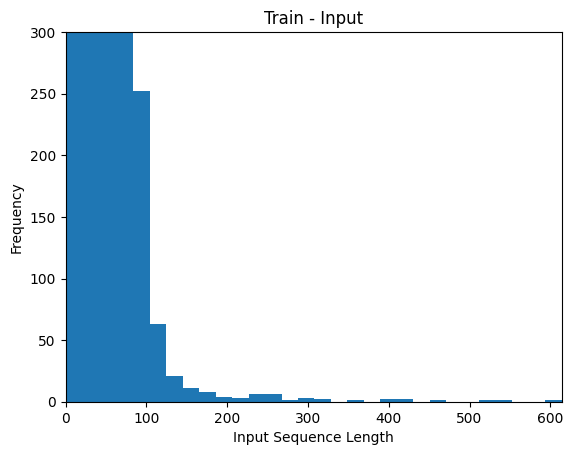

Total output words: 3301575
Average output length: 24.764846193658723
Max output length: 722


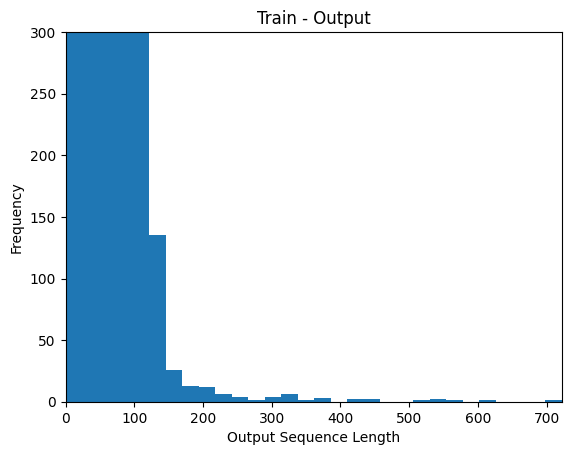

--- Validation ---
Total pairs: 1553
Total input words: 28801
Average input length: 18.54539600772698
Max input length: 92


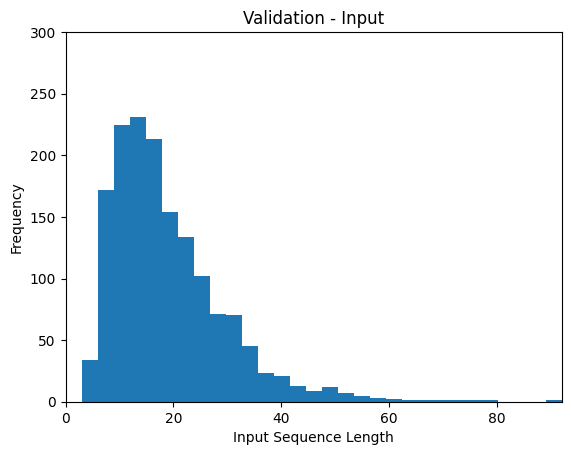

Total output words: 34876
Average output length: 22.457179652285898
Max output length: 119


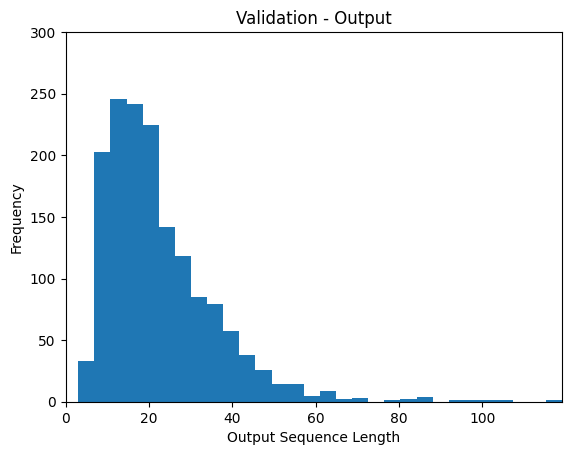

--- Test ---
Total pairs: 1268
Total input words: 26693
Average input length: 21.051261829652997
Max input length: 97


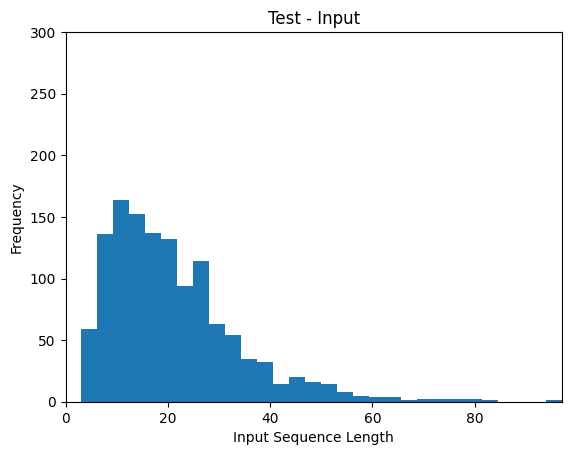

Total output words: 33370
Average output length: 26.317034700315457
Max output length: 120


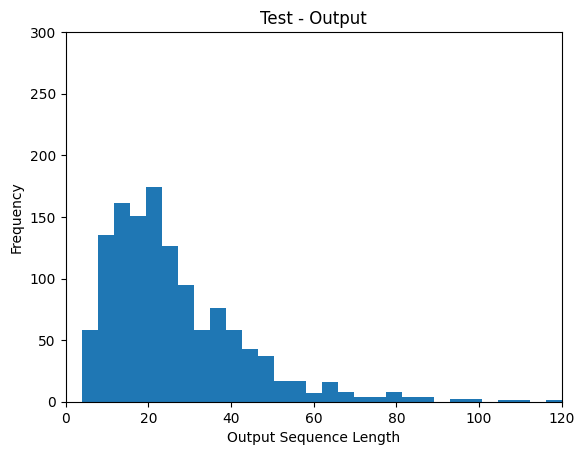

In [12]:
draw_diagram(train_pairs, name ="Train")
draw_diagram(val_pairs, name="Validation")
draw_diagram(test_pairs, name="Test")


## The sentences in the English-Vietnamese pair dataset have a length of no more than 60 words

In [13]:
def short_sentences(pairs):
  """
  Hàm lọc ra các câu Anh - Việt trọn vẹn có độ dài từ 60 chữ trở xuống, dựa trên số liệu đã thống kê
  và giới hạn bộ nhớ của GPU dùng để huấn luyện

  Tham số:
    pairs: list các cặp câu Anh - Việt

  Returns:
    List các cặp câu Anh - Việt có độ dài từ 60 chữ trở xuống
  """

  result = []

  for i in range(len(pairs)):
    if len(pairs[i][0].split()) <= 60 and len(pairs[i][1].split()) <= 60:
      result.append([pairs[i][0], pairs[i][1]])

  return result

short_train_pairs = short_sentences(train_pairs)
print_samples(short_train_pairs, 5)

<start> rachel pike the science behind a climate headline <end>
<start> khoa học đằng sau một tiêu đề về khí hậu <end>
<start> i apos d like to talk to you today about the scale of the scientific effort that goes into making the headlines you see in the paper <end>
<start> tôi muốn cho các bạn biết về sự to lớn của những nỗ lực khoa học đã góp phần làm nên các dòng tít bạn thường thấy trên báo <end>
<start> headlines that look like this when they have to do with climate change and headlines that look like this when they have to do with air quality or smog <end>
<start> có những dòng trông như thế này khi bàn về biến đổi khí hậu và như thế này khi nói về chất lượng không khí hay khói bụi <end>
<start> they are both two branches of the same field of atmospheric science <end>
<start> cả hai đều là một nhánh của cùng một lĩnh vực trong ngành khoa học khí quyển <end>
<start> recently the headlines looked like this when the intergovernmental panel on climate change or ipcc put out their repo

--- Short Train ---
Total pairs: 127978
Total input words: 2397982
Average input length: 18.73745487505665
Max input length: 60


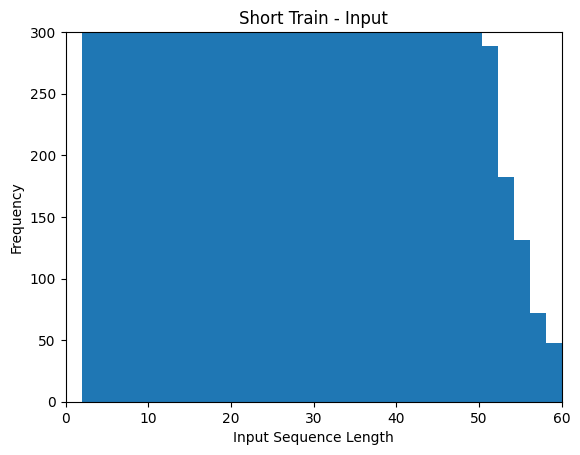

Total output words: 2875200
Average output length: 22.466361405866632
Max output length: 60


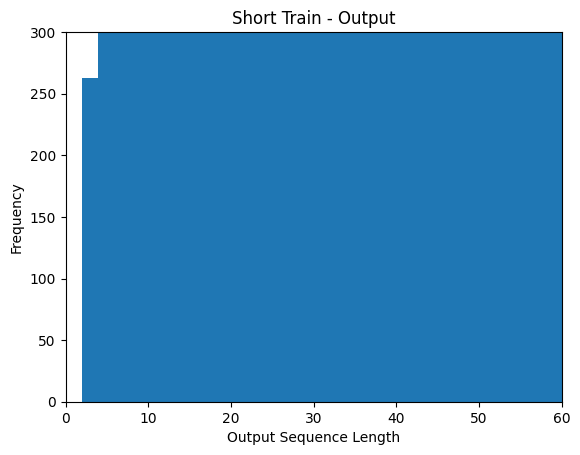

In [14]:
draw_diagram(short_train_pairs, name="Short Train")

## Preprocessing

In [15]:
class LanguageIndex:
    def __init__(self, lang):
        self.lang = lang
        self.word2idx = {}
        self.idx2word = {}
        self.vocab = set()
        self.create_index()

    def create_index(self):
        for phrase in self.lang:
            self.vocab.update(phrase.split())
        self.vocab = sorted(self.vocab)

        self.word2idx['<pad>'] = 0
        for index, word in enumerate(self.vocab):
            self.word2idx[word] = index + 1

        for word, index in self.word2idx.items():
            self.idx2word[index] = word

def max_length(tensor):
    return max(len(t) for t in tensor)

def load_train_dataset(input_path, target_path):
    pairs = create_dataset(input_path, target_path)

    inp_lang = LanguageIndex(en for en, vi in pairs)
    targ_lang = LanguageIndex(vi for en, vi in pairs)

    pairs = short_sentences(pairs)

    input_tensor = [[inp_lang.word2idx[word] for word in en.split()] for en, vi in pairs]
    target_tensor = [[targ_lang.word2idx[word] for word in vi.split()] for en, vi in pairs]

    input_tensor = [torch.tensor(t, dtype=torch.long) for t in input_tensor]
    target_tensor = [torch.tensor(t, dtype=torch.long) for t in target_tensor]

    input_tensor = pad_sequence(input_tensor, batch_first=True, padding_value=0)
    target_tensor = pad_sequence(target_tensor, batch_first=True, padding_value=0)

    max_length_inp = input_tensor.shape[1]
    max_length_tar = target_tensor.shape[1]

    return input_tensor, target_tensor, inp_lang, targ_lang, max_length_inp, max_length_tar

def load_val_dataset(input_path, target_path, inp_lang, targ_lang):
    pairs = create_dataset(input_path, target_path)

    input_tensor = []
    target_tensor = []

    for en, vi in pairs:
        inputs = [inp_lang.word2idx.get(word, 0) for word in en.split()]
        targets = [targ_lang.word2idx.get(word, 0) for word in vi.split()]

        input_tensor.append(torch.tensor(inputs, dtype=torch.long))
        target_tensor.append(torch.tensor(targets, dtype=torch.long))

    input_tensor = pad_sequence(input_tensor, batch_first=True, padding_value=0)
    target_tensor = pad_sequence(target_tensor, batch_first=True, padding_value=0)

    max_length_inp = input_tensor.shape[1]
    max_length_tar = target_tensor.shape[1]

    return input_tensor, target_tensor, inp_lang, targ_lang, max_length_inp, max_length_tar

input_tensor_train, target_tensor_train, inp_lang, targ_lang, max_length_inp, max_length_targ = load_train_dataset(train_en, train_vi)
input_tensor_val, target_tensor_val, inp_lang_val, targ_lang_val, max_length_inp_val, max_length_targ_val = load_val_dataset(validation_en, validation_vi, inp_lang, targ_lang)


In [16]:
# In ra độ dài vocab của tập Tiếng Anh và Tiếng Việt
print(len(inp_lang.word2idx))
print(len(targ_lang.word2idx))

# In ra độ dài lớn nhất trong tập câu Tiếng Anh và Tiếng Việt
print(max_length_inp, max_length_targ)

# In ra câu đầu tiên trong tensor Tiếng Anh
print(input_tensor_train[0])
print(target_tensor_train[0])

42137
19763
60 60
tensor([  802, 30170, 28133, 37659, 33048,  4136,   804,  7400, 17249,   801,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])
tensor([  963,  8788,  7865, 19526, 14902, 11465, 16924, 19546, 18301,  8874,
         7839,   962,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])


In [17]:
# In ra độ dài vocab của tập Tiếng Anh và Tiếng Việt
print(len(inp_lang_val.word2idx))
print(len(targ_lang_val.word2idx))

# In ra độ dài lớn nhất trong tập câu Tiếng Anh và Tiếng Việt
print(max_length_inp_val, max_length_targ_val)

# In ra câu đầu tiên trong tensor Tiếng Anh
print(input_tensor_val[0])
print(target_tensor_val[0])

42137
19763
92 119
tensor([  802, 18050,  6089, 18342, 35124, 18768,    31, 24011,   901, 37659,
         5005, 26106, 41544, 26681, 37832, 15692,   901, 18050, 37659,  3041,
        36050, 26106, 37806,  5005, 38188, 17778, 18768, 37659, 21809, 26106,
          804, 14999, 41853, 26180, 15947, 18089, 41476, 17470, 41943, 34305,
        17470, 24563,  2158, 17470, 16351, 14816, 14458,  9845,  2158, 25544,
        18768,   804, 34605,  4905, 18768, 37659,  7027, 33200, 24479, 37643,
          486, 41862,  1568,  5005, 37653, 38188, 17778, 18768, 37659, 21809,
        26106, 37653, 34605, 15947,  2158, 25418, 21675, 16107, 37653, 34605,
        15947, 25818, 22033, 18768, 32703, 15068,  2158, 35127, 38092, 41941,
        38106,   801])
tensor([  963,  9910, 14862, 17580,  4373, 16785, 17232,  2833, 17166,    32,
        13365, 18301, 16130,  5149,  9666,  9286, 12236, 11892, 13426, 12628,
        13818,  1833, 16778,  7860, 18301, 18105,  9910, 16778, 12466, 12236,
        16130,  5149, 

# Model Building

## Using Positional Encoding with TransformerModel

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
# Create TensorDataset and DataLoader
batch_size = 16
train_dataset = TensorDataset(input_tensor_train, target_tensor_train)
val_dataset = TensorDataset(input_tensor_val, target_tensor_val)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

# Define PositionalEncoding class
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# Define TransformerModel class
class TransformerModel(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=128, nhead=2, num_encoder_layers=3,
                 num_decoder_layers=3, dim_feedforward=512, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, src_key_padding_mask=None,
                tgt_key_padding_mask=None):
        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt) * math.sqrt(self.d_model))
        output = self.transformer(
            src_emb, tgt_emb, src_mask=src_mask, tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask, tgt_key_padding_mask=tgt_key_padding_mask
        )
        return self.fc_out(output)

    def generate_square_subsequent_mask(self, sz):
        mask = torch.triu(torch.ones(sz, sz, dtype=torch.bool), diagonal=1)
        return mask

# Initialize the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerModel(
    src_vocab_size=len(inp_lang.vocab) + 1,
    tgt_vocab_size=len(targ_lang.vocab) + 1,
    d_model=128,
    nhead=2,
    num_encoder_layers=3,
    num_decoder_layers=3,
    dim_feedforward=512,
    dropout=0.1
).to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

## Train model

In [ ]:
# Training function with gradient accumulation
accumulation_steps = 2
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    scaler = GradScaler('cuda')
    optimizer.zero_grad(set_to_none=True)

    for i, (src, tgt) in enumerate(train_loader):
        src = src.to(device)
        tgt = tgt.to(device)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]
        tgt_mask = model.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
        src_key_padding_mask = (src == 0).bool().to(device)
        tgt_key_padding_mask = (tgt_input == 0).bool().to(device)

        with autocast('cuda'):
            output = model(
                src, tgt_input, tgt_mask=tgt_mask,
                src_key_padding_mask=src_key_padding_mask,
                tgt_key_padding_mask=tgt_key_padding_mask
            )
            loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
            loss = loss / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * accumulation_steps

    return total_loss / len(train_loader)

In [ ]:
# Evaluation function
def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            src = src.to(device)
            tgt = tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]
            tgt_mask = model.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
            src_key_padding_mask = (src == 0).bool().to(device)
            tgt_key_padding_mask = (tgt_input == 0).bool().to(device)
            with autocast('cuda'):
                output = model(
                    src, tgt_input, tgt_mask=tgt_mask,
                    src_key_padding_mask=src_key_padding_mask,
                    tgt_key_padding_mask=tgt_key_padding_mask
                )
                loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(val_loader)

# Train the model
num_epochs = 20
for epoch in range(num_epochs):
    start_time = time.time()
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    epoch_time = time.time() - start_time
    print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Time: {epoch_time/60:.2f} minutes')

Epoch 1, Train Loss: 2.7994, Val Loss: 2.8669, Time: 3.62 minutes
Epoch 2, Train Loss: 2.7356, Val Loss: 2.8516, Time: 3.63 minutes
Epoch 3, Train Loss: 2.6828, Val Loss: 2.8248, Time: 3.58 minutes
Epoch 4, Train Loss: 2.6347, Val Loss: 2.8094, Time: 3.57 minutes
Epoch 5, Train Loss: 2.5973, Val Loss: 2.7760, Time: 3.58 minutes
Epoch 6, Train Loss: 2.5643, Val Loss: 2.7645, Time: 3.59 minutes
Epoch 7, Train Loss: 2.5309, Val Loss: 2.7548, Time: 3.63 minutes
Epoch 8, Train Loss: 2.5000, Val Loss: 2.7293, Time: 3.57 minutes
Epoch 9, Train Loss: 2.4731, Val Loss: 2.7141, Time: 3.57 minutes
Epoch 10, Train Loss: 2.4507, Val Loss: 2.7040, Time: 3.56 minutes
Epoch 11, Train Loss: 2.4253, Val Loss: 2.6921, Time: 3.57 minutes
Epoch 12, Train Loss: 2.4046, Val Loss: 2.6883, Time: 3.57 minutes
Epoch 13, Train Loss: 2.3865, Val Loss: 2.6825, Time: 3.58 minutes
Epoch 14, Train Loss: 2.3676, Val Loss: 2.6752, Time: 3.60 minutes
Epoch 15, Train Loss: 2.3503, Val Loss: 2.6603, Time: 3.59 minutes
Epoc

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Sử dụng hàm để in số lượng tham số
total_params = count_parameters(model)
print(f"Tổng số tham số có thể huấn luyện: {total_params}")

Tổng số tham số có thể huấn luyện: 11861683


In [ ]:
def translate_sentence(model, sentence, inp_lang, targ_lang, max_length=60, device='cuda'):
    model.eval()
    # Tiền xử lý câu (giả sử bạn có hàm preprocess_sentence)
    sentence = preprocess_sentence(sentence)
    # Chuyển câu thành tensor
    src = [inp_lang.word2idx.get(word, 0) for word in sentence.split()]
    src = torch.tensor([src], dtype=torch.long).to(device)

    # Khởi tạo target với token <start>
    tgt = torch.tensor([[targ_lang.word2idx['<start>']]], dtype=torch.long).to(device)
    output_sentence = []

    with torch.no_grad():
        for _ in range(max_length):
            tgt_mask = model.generate_square_subsequent_mask(tgt.size(1)).to(device)
            src_key_padding_mask = (src == 0).to(device)
            tgt_key_padding_mask = (tgt == 0).to(device)

            output = model(
                src, tgt, tgt_mask=tgt_mask,
                src_key_padding_mask=src_key_padding_mask,
                tgt_key_padding_mask=tgt_key_padding_mask
            )

            next_word_idx = output[:, -1, :].argmax(-1).item()  # Lấy từ có xác suất cao nhất
            if next_word_idx == targ_lang.word2idx['<end>']:  # Dừng nếu gặp <end>
                break
            output_sentence.append(targ_lang.idx2word[next_word_idx])  # Thêm từ vào kết quả
            tgt = torch.cat([tgt, torch.tensor([[next_word_idx]], dtype=torch.long).to(device)], dim=1)

    return ' '.join(output_sentence)  # Trả về câu đã dịch


sentence = "I love to learn new things."
translated = translate_sentence(model, sentence, inp_lang, targ_lang, device='cuda')
print(f"Dịch: {translated}")

Dịch: tôi thích học những điều mới


## Save model

In [ ]:
# Save the model
def save_model(model, path='transformer_model.pth'):
    """
    Save the trained model to a file.

    Args:
        model: The trained PyTorch model to save
        path: File path to save the model (default: 'transformer_model.pth')
    """
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")

# Load the model
def load_model(model_class, path='transformer_model.pth', device='cpu'):
    """
    Load a saved model from a file.

    Args:
        model_class: The model class (e.g., TransformerModel)
        path: File path to load the model from
        device: Device to load the model onto ('cpu' or 'cuda')

    Returns:
        Loaded model instance
    """
    model = model_class(
        src_vocab_size=len(inp_lang.vocab) + 1,
        tgt_vocab_size=len(targ_lang.vocab) + 1,
        d_model=128,
        nhead=2,
        num_encoder_layers=3,
        num_decoder_layers=3,
        dim_feedforward=512,
        dropout=0.1
    ).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"Model loaded from {path}")
    return model

In [ ]:
# Save the trained model
save_model(model, path='transformer_model.pth')

# Load the model (for demonstration; in practice, you might load it later)
loaded_model = load_model(TransformerModel, path='transformer_model.pth', device=device)

Model saved to transformer_model.pth
Model loaded from transformer_model.pth


## Translation sample

In [ ]:
def translate(model, src_sentence, inp_lang, targ_lang, max_len=50, device='cpu'):
    model.eval()

    # Tiền xử lý câu
    src = preprocess_sentence(src_sentence)
    src = [inp_lang.word2idx.get(word, 0) for word in src.split()]
    src = torch.tensor([src], dtype=torch.long).to(device)

    # Khởi tạo target với <start>
    tgt = torch.tensor([[targ_lang.word2idx['<start>']]], dtype=torch.long).to(device)

    output_sentence = []

    with torch.no_grad():
        for _ in range(max_len):
            tgt_mask = model.generate_square_subsequent_mask(tgt.size(1)).to(device)
            src_key_padding_mask = (src == 0).to(device)
            tgt_key_padding_mask = (tgt == 0).to(device)

            output = model(
                src,
                tgt,
                tgt_mask=tgt_mask,
                src_key_padding_mask=src_key_padding_mask,
                tgt_key_padding_mask=tgt_key_padding_mask
            )

            next_word_idx = output[:, -1, :].argmax(-1).item()
            if next_word_idx == targ_lang.word2idx['<end>']:
                break

            output_sentence.append(targ_lang.idx2word[next_word_idx])
            tgt = torch.cat([tgt, torch.tensor([[next_word_idx]], dtype=torch.long).to(device)], dim=1)

    return ' '.join(output_sentence)

sentence = "I love to learn new things."
translated = translate(model, sentence, inp_lang, targ_lang, device='cuda')
print(f"Dịch: {translated}")

Dịch: tôi thích học những điều mới


# Evaluate

## Test Data

In [ ]:
# !pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.8 MB/s eta 0:00:00


In [ ]:
from sacrebleu import corpus_bleu

# Evaluate on test set (loss and BLEU)
def evaluate_test_set(model, test_loader, criterion, inp_lang, targ_lang, device):
    """
    Evaluate the model on the test set, computing loss and BLEU score.

    Args:
        model: The trained model
        test_loader: DataLoader for the test set
        criterion: Loss function (e.g., CrossEntropyLoss)
        inp_lang: Source language vocabulary (LanguageIndex)
        targ_lang: Target language vocabulary (LanguageIndex)
        device: Device to run evaluation on ('cpu' or 'cuda')

    Returns:
        tuple: (average test loss, BLEU score)
    """
    model.eval()
    total_loss = 0
    predictions = []
    references = []

    with torch.no_grad():
        for src, tgt in test_loader:
            src = src.to(device)
            tgt = tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]
            tgt_mask = model.generate_square_subsequent_mask(tgt_input.size(1)).to(device)
            src_key_padding_mask = (src == 0).bool().to(device)
            tgt_key_padding_mask = (tgt_input == 0).bool().to(device)

            # Compute loss
            output = model(
                src, tgt_input, tgt_mask=tgt_mask,
                src_key_padding_mask=src_key_padding_mask,
                tgt_key_padding_mask=tgt_key_padding_mask
            )
            loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
            total_loss += loss.item()

            # Generate translations for BLEU
            for i in range(src.size(0)):
                src_sent = src[i:i+1]
                pred = translate(model, src_sent, inp_lang, targ_lang, max_len=50, device=device)
                predictions.append(pred)
                # Convert target tensor to string, excluding <start>, <end>, <pad>
                tgt_words = [targ_lang.idx2word[idx.item()] for idx in tgt[i] if idx.item() != 0
                             and targ_lang.idx2word[idx.item()] not in ['<start>', '<end>']]
                references.append(' '.join(tgt_words))

    avg_loss = total_loss / len(test_loader)
    bleu_score = corpus_bleu(predictions, [references]).score
    return avg_loss, bleu_score

# Modified translate function to handle tensor input (for evaluation)
def translate(model, src_tensor, inp_lang, targ_lang, max_len=50, device='cpu'):
    """
    Translate a source tensor to a target sentence.

    Args:
        model: The trained model
        src_tensor: Source sentence tensor (shape: [1, seq_len])
        inp_lang: Source language vocabulary
        targ_lang: Target language vocabulary
        max_len: Maximum length of generated translation
        device: Device to run translation on

    Returns:
        str: Translated sentence
    """
    model.eval()
    src = src_tensor.to(device)
    tgt = torch.tensor([[targ_lang.word2idx['<start>']]], dtype=torch.long).to(device)
    output_sentence = []

    with torch.no_grad():
        for _ in range(max_len):
            tgt_mask = model.generate_square_subsequent_mask(tgt.size(1)).to(device)
            src_key_padding_mask = (src == 0).to(device)
            tgt_key_padding_mask = (tgt == 0).to(device)

            output = model(
                src, tgt, tgt_mask=tgt_mask,
                src_key_padding_mask=src_key_padding_mask,
                tgt_key_padding_mask=tgt_key_padding_mask
            )
            next_word_idx = output[:, -1, :].argmax(-1).item()
            if next_word_idx == targ_lang.word2idx['<end>']:
                break
            output_sentence.append(targ_lang.idx2word[next_word_idx])
            tgt = torch.cat([tgt, torch.tensor([[next_word_idx]], dtype=torch.long).to(device)], dim=1)

    return ' '.join(output_sentence)

# Load and prepare test dataset
input_tensor_test, target_tensor_test, inp_lang_test, targ_lang_test, max_length_inp_test, max_length_targ_test = load_val_dataset(
    test_en, test_vi, inp_lang, targ_lang
)

In [ ]:
# Create test DataLoader
batch_size = 16
test_dataset = TensorDataset(input_tensor_test, target_tensor_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

# Evaluate on test set
test_loss, test_bleu = evaluate_test_set(loaded_model, test_loader, criterion, inp_lang, targ_lang, device)
print(f"Test Loss: {test_loss:.4f}, Test BLEU: {test_bleu:.2f}")

Test Loss: 2.6432, Test BLEU: 22.92


In [ ]:
def print_test_translations(model, test_pairs, inp_lang, targ_lang, num_samples=10, device='cuda'):
    for i in range(min(num_samples, len(test_pairs))):
        en_sentence = test_pairs[i][0]
        vi_true = test_pairs[i][1]
        vi_pred = translate_sentence(model, en_sentence, inp_lang, targ_lang, device=device)
        print(f"Câu tiếng Anh: {en_sentence}")
        print(f"Tiếng Việt thực tế: {vi_true}")
        print(f"Tiếng Việt dự đoán: {vi_pred}")
        print()

# In 5 câu dịch thử
test_pairs = create_dataset(test_en, test_vi)  # List các cặp [en, vi]
print_test_translations(model, test_pairs, inp_lang, targ_lang)

Câu tiếng Anh: <start> when i was little i thought my country was the best on the planet and i grew up singing a song called quot nothing to envy quot <end>
Tiếng Việt thực tế: <start> khi tôi còn nhỏ tôi nghĩ rằng bắctriều tiên là đất nước tốt nhất trên thế giới và tôi thường hát bài quot chúng ta chẳng có gì phải ghen tị quot <end>
Tiếng Việt dự đoán: khi tôi nhỏ tôi nghĩ đất nước tôi là người tốt nhất trên hành tinh và tôi lớn lên hát một bài hát gọi là quot không có gì khiến họ ngọt ngào quot

Câu tiếng Anh: <start> and i was very proud <end>
Tiếng Việt thực tế: <start> tôi đã rất tự hào về đất nước tôi <end>
Tiếng Việt dự đoán: tôi rất tự hào

Câu tiếng Anh: <start> in school we spent a lot of time studying the history of kim il sung but we never learned much about the outside world except that america south korea japan are the enemies <end>
Tiếng Việt thực tế: <start> ở trường chúng tôi dành rất nhiều thời gian để học về cuộc đời của chủ tịch kim ii sung nhưng lại không học nhiều

# Trying the pre-trained model google-t5/t5-small

In [ ]:
# !pip install transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
# from transformers import T5Tokenizer, T5ForConditionalGeneration

# Load model directly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM



# Import AdamW from torch.optim instead of transformers
from torch.optim import AdamW
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load tokenizer + model
# tokenizer = T5Tokenizer.from_pretrained("google-t5/t5-small")
# model = T5ForConditionalGeneration.from_pretrained("google-t5/t5-small").to(device)


tokenizer = AutoTokenizer.from_pretrained("google-t5/t5-small")
model = AutoModelForSeq2SeqLM.from_pretrained("google-t5/t5-small").to(device)

# === Dataset Class ===
class TranslationDataset(Dataset):
    def __init__(self, src_texts, tgt_texts, tokenizer, max_len=128):
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        input_text = "translate English to Vietnamese: " + self.src_texts[idx]
        target_text = self.tgt_texts[idx]

        input_enc = self.tokenizer(
            input_text, max_length=self.max_len, padding="max_length", truncation=True, return_tensors="pt"
        )
        target_enc = self.tokenizer(
            target_text, max_length=self.max_len, padding="max_length", truncation=True, return_tensors="pt"
        )

        labels = target_enc["input_ids"].squeeze()
        labels[labels == tokenizer.pad_token_id] = -100  # IMPORTANT!

        return {
            'input_ids': input_enc['input_ids'].squeeze(),
            'attention_mask': input_enc['attention_mask'].squeeze(),
            'labels': labels
        }

# === Hàm convert tensor sang câu ===
def tensor_to_sentence(tensor, idx2word):
    words = [idx2word.get(idx.item(), '') for idx in tensor if idx.item() != 0]
    return ' '.join(words)


src_train = [tensor_to_sentence(t, inp_lang.idx2word) for t in input_tensor_train]
tgt_train = [tensor_to_sentence(t, targ_lang.idx2word) for t in target_tensor_train]
src_val = [tensor_to_sentence(t, inp_lang.idx2word) for t in input_tensor_val]
tgt_val = [tensor_to_sentence(t, targ_lang.idx2word) for t in target_tensor_val]

train_dataset = TranslationDataset(src_train, tgt_train, tokenizer)
val_dataset = TranslationDataset(src_val, tgt_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [19]:
# === Optimizer ===
optimizer = AdamW(model.parameters(), lr=5e-5)

# === Train & Eval ===
def train_model(model, dataloader, optimizer):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
    return total_loss / len(dataloader)

In [20]:
train_loss = train_model(model, train_loader, optimizer)
val_loss = evaluate(model, val_loader)
print(f"[Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Training: 100%|██████████| 7999/7999 [37:51<00:00,  3.52it/s]


[Train Loss: 1.4709, Val Loss: 1.1443


In [21]:
def translate_sentence(sentence, tokenizer, model, device, max_len=128):
    input_text = "translate English to Vietnamese: " + sentence
    inputs = tokenizer(input_text, return_tensors="pt", padding=True, truncation=True).to(device)
    output_ids = model.generate(
        input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'],
        max_length=max_len, num_beams=4, early_stopping=True
    )
    translated = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return translated

translated = translate_sentence("I love to learn new things.", tokenizer, model, device)
print(f"Dịch: {translated}")


Dịch: iu tôi hc nhng iu nhng iu nhng iu này tr nhng iu iu iu iu iu iu iu iu iu iu iu tôi 
